In [14]:
import pulp
import numpy as np
import pandas as pd

# 1. Khởi tạo dữ liệu từ bảng 4.3 và mô hình 4.2 [6, 7]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

# Hệ số tác động biên beta [3, 7]
beta = {
    ('Trung du MN phía Bắc','I'):1.15, ('Trung du MN phía Bắc','D'):0.85, ('Trung du MN phía Bắc','AI'):0.55, ('Trung du MN phía Bắc','H'):1.30,
    ('Đồng bằng sông Hồng','I'):0.95, ('Đồng bằng sông Hồng','D'):1.25, ('Đồng bằng sông Hồng','AI'):1.40, ('Đồng bằng sông Hồng','H'):1.05,
    ('Bắc Trung Bộ & DH MT','I'):1.05, ('Bắc Trung Bộ & DH MT','D'):0.95, ('Bắc Trung Bộ & DH MT','AI'):0.85, ('Bắc Trung Bộ & DH MT','H'):1.15,
    ('Tây Nguyên','I'):1.20, ('Tây Nguyên','D'):0.75, ('Tây Nguyên','AI'):0.45, ('Tây Nguyên','H'):1.35,
    ('Đông Nam Bộ','I'):0.90, ('Đông Nam Bộ','D'):1.30, ('Đông Nam Bộ','AI'):1.55, ('Đông Nam Bộ','H'):1.00,
    ('ĐBSCL','I'):1.10, ('ĐBSCL','D'):0.85, ('ĐBSCL','AI'):0.65, ('ĐBSCL','H'):1.25
}

# Chỉ số số hóa ban đầu D0 và các tham số C5 [6, 7]
D0 = {
    'Trung du MN phía Bắc':38, 'Đồng bằng sông Hồng':78, 'Bắc Trung Bộ & DH MT':55, 
    'Tây Nguyên':32, 'Đông Nam Bộ':82, 'ĐBSCL':48
}
gamma, lam = 0.002, 0.7

# 2. Thiết lập mô hình LP [7]
m = pulp.LpProblem('VN_Digital_Budget_Allocation', pulp.LpMaximize)

# Biến quyết định x[r][j] >= 0 [4, 7]
x = pulp.LpVariable.dicts('x', (regions, items), lowBound=0)

# Biến phụ M để tuyến tính hóa ràng buộc Max (C5) [5]
M = pulp.LpVariable('Dmax', lowBound=0)

# 3. Hàm mục tiêu: Tối đa hóa GDP gain (Z) [2, 7]
m += pulp.lpSum(beta[(r,j)] * x[r][j] for r in regions for j in items)

# 4. Các ràng buộc (Constraints) [4, 5, 7]
# (C1) Ngân sách tổng <= 50.000 tỷ
m += pulp.lpSum(x[r][j] for r in regions for j in items) <= 50000

# (C2) & (C3) Sàn (5.000) và Trần (12.000) ngân sách mỗi vùng
for r in regions:
    m += pulp.lpSum(x[r][j] for j in items) >= 5000
    m += pulp.lpSum(x[r][j] for j in items) <= 12000

# (C4) Sàn nhân lực số (H) >= 12.000 tỷ
m += pulp.lpSum(x[r]['H'] for r in regions) >= 12000

# (C5) Ràng buộc công bằng vùng miền
for r in regions:
    # M là giá trị lớn nhất của chỉ số số hóa sau đầu tư
    m += D0[r] + gamma * x[r]['D'] <= M
    # Chỉ số của mỗi vùng phải đạt ít nhất 70% (lam=0.7) giá trị cao nhất
    m += D0[r] + gamma * x[r]['D'] >= lam * M

# 5. Giải bài toán bằng solver CBC mặc định [5, 8]
m.solve(pulp.PULP_CBC_CMD(msg=False))

# 6. In kết quả dưới dạng ma trận 6x4 và giá trị Z* [8]
print(f"--- KẾT QUẢ TỐI ƯU DÙNG THƯ VIỆN PuLP VỚI SOLVER CBC (Z*) ---")
print(f"Z* = {pulp.value(m.objective):,.2f} tỷ VND\n")

# Chuyển đổi kết quả sang DataFrame để in dạng ma trận
results = []
for r in regions:
    row = [pulp.value(x[r][j]) for j in items]
    results.append(row)

df_res = pd.DataFrame(results, index=regions, columns=items)

print("--- MA TRẬN PHÂN BỔ TỐI ƯU x_{j,r} (6x4) ---")
print(df_res.round(2))

# --- PHẦN LƯU KẾT QUẢ THEO CẤU TRÚC PHỤ LỤC F1.4 ---
# '..' giúp lùi lại 1 cấp từ thư mục 'notebooks' để vào 'outputs' trong thư mục mẹ 'aideom_vn'
output_dir = os.path.join('..', 'outputs')

# Tạo thư mục nếu chưa tồn tại
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Lưu ma trận dưới dạng CSV
file_name = 'matrix_pulp_441.csv'
save_path = os.path.join(output_dir, file_name)
df_res.to_csv(save_path, encoding='utf-8-sig')

print(f"\n[Thông báo] Ma trận kết quả đã được lưu tại: {os.path.abspath(save_path)}")

--- KẾT QUẢ TỐI ƯU DÙNG THƯ VIỆN PuLP VỚI SOLVER CBC (Z*) ---
Z* = 52,485.00 tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU x_{j,r} (6x4) ---
                        I        D      AI       H
Trung du MN phía Bắc  0.0   9700.0     0.0  2300.0
Đồng bằng sông Hồng   0.0      0.0  5000.0     0.0
Bắc Trung Bộ & DH MT  0.0   1200.0     0.0  3800.0
Tây Nguyên            0.0  12000.0     0.0     0.0
Đông Nam Bộ           0.0      0.0  5400.0     0.0
ĐBSCL                 0.0   4700.0     0.0  5900.0

[Thông báo] Ma trận kết quả đã được lưu tại: D:\aideom_vn\outputs\matrix_pulp_441.csv


In [24]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. Dữ liệu chuẩn từ Bảng 4.3 [2]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], 
    [0.95, 1.25, 1.40, 1.05], 
    [1.05, 0.95, 0.85, 1.15], 
    [1.20, 0.75, 0.45, 1.35], 
    [0.90, 1.30, 1.55, 1.00], 
    [1.10, 0.85, 0.65, 1.25]
])

# D0 đúng: D1=38, D2=78, D3=55, D4=32, D5=82, D6=48 [2]
D0 = np.array([38, 78, 55, 32, 82, 48])
gamma, lam = 0.002, 0.7

# 2. Thiết lập biến và hàm mục tiêu
x = cp.Variable((6, 4), nonneg=True)
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, x)))

# 3. Các ràng buộc (C1-C5) [9]
constraints = [
    cp.sum(x) <= 50000,
    cp.sum(x, axis=1) >= 5000,
    cp.sum(x, axis=1) <= 12000,
    cp.sum(x[:, 3]) >= 12000
]
D_final = D0 + gamma * x[:, 1]
constraints.append(D_final >= lam * cp.max(D_final))

# 4. Giải bằng solver HiGHS (đã cài đặt)
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.HIGHS) 

# 5. In kết quả
print(f"--- KẾT QUẢ TỐI ƯU DÙNG THƯ VIỆN CVXPY VỚI SOLVER HIGHS (Z*) ---")
print(f"Z* = {prob.value:,.2f} tỷ VND")

df_cvxpy = pd.DataFrame(x.value, index=regions, columns=items)
print("\n--- MA TRẬN PHÂN BỔ TỐI ƯU ---")
print(df_cvxpy.round(2))


--- KẾT QUẢ TỐI ƯU DÙNG THƯ VIỆN CVXPY VỚI SOLVER HIGHS (Z*) ---
Z* = -inf tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU ---
                        I    D   AI    H
Trung du MN phía Bắc  NaN  NaN  NaN  NaN
Đồng bằng sông Hồng   NaN  NaN  NaN  NaN
Bắc Trung Bộ & DH MT  NaN  NaN  NaN  NaN
Tây Nguyên            NaN  NaN  NaN  NaN
Đông Nam Bộ           NaN  NaN  NaN  NaN
ĐBSCL                 NaN  NaN  NaN  NaN


In [13]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. Dữ liệu chuẩn từ Bảng 4.3 [2]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], 
    [0.95, 1.25, 1.40, 1.05], 
    [1.05, 0.95, 0.85, 1.15], 
    [1.20, 0.75, 0.45, 1.35], 
    [0.90, 1.30, 1.55, 1.00], 
    [1.10, 0.85, 0.65, 1.25]
])

# D0 đúng: D1=38, D2=78, D3=55, D4=32, D5=82, D6=48 [2]
D0 = np.array([38, 78, 55, 32, 82, 48])
gamma, lam = 0.002, 0.7

# 2. Thiết lập biến và hàm mục tiêu
x = cp.Variable((6, 4), nonneg=True)
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, x)))

# 3. Các ràng buộc (C1-C5) [9]
constraints = [
    cp.sum(x) <= 50000,
    cp.sum(x, axis=1) >= 5000,
    cp.sum(x, axis=1) <= 12000,
    cp.sum(x[:, 3]) >= 12000
]
D_final = D0 + gamma * x[:, 1]
constraints.append(D_final >= lam * cp.max(D_final))

# 4. Giải bằng solver HiGHS (đã cài đặt)
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS) 

# 5. In kết quả
print(f"--- KẾT QUẢ TỐI ƯU DÙNG THƯ VIỆN CVXPY VỚI SOLVER SCS (Z*) ---")
print(f"Z* = {prob.value:,.2f} tỷ VND")

df_cvxpy = pd.DataFrame(x.value, index=regions, columns=items)
print("\n--- MA TRẬN PHÂN BỔ TỐI ƯU ---")
print(df_cvxpy.round(2))

--- KẾT QUẢ TỐI ƯU DÙNG THƯ VIỆN CVXPY VỚI SOLVER SCS (Z*) ---
Z* = 56,489.16 tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU ---
                         I         D        AI        H
Trung du MN phía Bắc  0.39  11440.83      0.39   557.95
Đồng bằng sông Hồng   0.00      0.00   5002.94     0.00
Bắc Trung Bộ & DH MT  1.22      1.22      1.22  4994.04
Tây Nguyên            0.37   9975.22      0.37  2023.65
Đông Nam Bộ           0.08      0.07  11001.85     0.00
ĐBSCL                 0.36    571.31      0.36  4427.58


C:\Users\Personal\AppData\Local\Temp\ipykernel_16876\1862093215.py:39: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS)


In [8]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. Dữ liệu chuẩn từ Bảng 4.3 và Phụ lục [2]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

# Ma trận hệ số beta (6 vùng x 4 hạng mục) [2]
beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], # Vùng 1
    [0.95, 1.25, 1.40, 1.05], # Vùng 2
    [1.05, 0.95, 0.85, 1.15], # Vùng 3
    [1.20, 0.75, 0.45, 1.35], # Vùng 4
    [0.90, 1.30, 1.55, 1.00], # Vùng 5
    [1.10, 0.85, 0.65, 1.25]  # Vùng 6
])

# Chỉ số số hóa ban đầu Dr [2]
D0 = np.array([38, 78, 55, 32, 82, 48])
gamma = 0.002

# ÁP DỤNG PHƯƠNG ÁN ĐIỀU CHỈNH CHÍNH SÁCH: Giảm lam xuống 0.68
lam = 0.68 

# 2. Khai báo biến quyết định (Ma trận 6x4) [9]
x = cp.Variable((6, 4), nonneg=True)

# 3. Định nghĩa hàm mục tiêu: Tối đa hóa GDP Gain (Z) [9]
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, x)))

# 4. Các ràng buộc (C1-C5) [1]
constraints = [
    cp.sum(x) <= 50000,                      # (C1) Ngân sách tổng
    cp.sum(x, axis=1) >= 5000,               # (C2) Sàn mỗi vùng
    cp.sum(x, axis=1) <= 12000,              # (C3) Trần mỗi vùng
    cp.sum(x[:, 3]) >= 12000                 # (C4) Sàn nhân lực số
]

# (C5) Ràng buộc công bằng vùng miền: D_r_sau_đầu_tư >= lam * D_max_sau_đầu_tư [1]
D_final = D0 + gamma * x[:, 1]
constraints.append(D_final >= lam * cp.max(D_final))

# 5. Giải bài toán bằng solver HiGHS [10]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.HIGHS) 

# 6. In kết quả và đối chiếu với yêu cầu 4.4.2 [11]
if prob.status == 'optimal':
    print(f"--- KẾT QUẢ TỐI ƯU GIẢI PHÁP 1 ---")
    print(f"Z* = {prob.value:,.2f} tỷ VND")
    
    df_cvxpy = pd.DataFrame(x.value, index=regions, columns=items)
    print("\n--- MA TRẬN PHÂN BỔ TỐI ƯU x_{j,r} ---")
    print(df_cvxpy.round(2))
else:
    print(f"Bài toán vẫn không khả thi với lam={lam}. Trạng thái: {prob.status}")


--- KẾT QUẢ TỐI ƯU GIẢI PHÁP 1 ---
Z* = 54,192.00 tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU x_{j,r} ---
                        I        D      AI       H
Trung du MN phía Bắc  0.0   8880.0     0.0  3120.0
Đồng bằng sông Hồng   0.0      0.0  5000.0     0.0
Bắc Trung Bộ & DH MT  0.0    380.0     0.0  4620.0
Tây Nguyên            0.0  11880.0     0.0   120.0
Đông Nam Bộ           0.0      0.0  7980.0     0.0
ĐBSCL                 0.0   3880.0     0.0  4140.0


In [9]:
import cvxpy as cp
import numpy as np
import pandas as pd

# 1. Dữ liệu chuẩn từ Bảng 4.3 [2]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], 
    [0.95, 1.25, 1.40, 1.05], 
    [1.05, 0.95, 0.85, 1.15], 
    [1.20, 0.75, 0.45, 1.35], 
    [0.90, 1.30, 1.55, 1.00], 
    [1.10, 0.85, 0.65, 1.25]
])

D0 = np.array([38, 78, 55, 32, 82, 48]) # [2]
gamma, lam = 0.002, 0.7 # lam giữ nguyên 0.7 theo yêu cầu công bằng cao [1]

# 2. Khai báo biến quyết định
x = cp.Variable((6, 4), nonneg=True)

# 3. Hàm mục tiêu: Tối đa hóa GDP gain
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, x)))

# 4. Thiết lập ràng buộc
# Phương án: Nới trần ngân sách (C3) cho Tây Nguyên (vùng index 3) lên 15.000 tỷ
upper_bounds = np.array(12700)

constraints = [
    cp.sum(x) <= 50000,                      # (C1) Tổng ngân sách vẫn giữ 50.000 [1]
    cp.sum(x, axis=1) >= 5000,               # (C2) Sàn mỗi vùng [1]
    cp.sum(x, axis=1) <= upper_bounds,       # (C3) Trần ngân sách đã được điều chỉnh
    cp.sum(x[:, 3]) >= 12000                 # (C4) Sàn nhân lực số [1]
]

# (C5) Công bằng vùng miền (giữ nguyên lam = 0.7) [1]
D_final = D0 + gamma * x[:, 1]
constraints.append(D_final >= lam * cp.max(D_final))

# 5. Giải bài toán bằng solver HiGHS
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.HIGHS) 

# 6. In kết quả
if prob.status == 'optimal':
    print(f"--- KẾT QUẢ TỐI ƯU GIẢI PHÁP 2 ---")
    print(f"Z* = {prob.value:,.2f} tỷ VND")
    
    df_cvxpy = pd.DataFrame(x.value, index=regions, columns=items)
    df_cvxpy['Tổng vùng'] = df_cvxpy.sum(axis=1)
    print("\n--- MA TRẬN PHÂN BỔ TỐI ƯU ---")
    print(df_cvxpy.round(2))
else:
    print("Mô hình vẫn không khả thi. Cần nới trần cao hơn nữa hoặc tăng tổng ngân sách.")



--- KẾT QUẢ TỐI ƯU GIẢI PHÁP 2 ---
Z* = 51,945.00 tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU ---
                        I        D      AI       H  Tổng vùng
Trung du MN phía Bắc  0.0   9700.0     0.0  3000.0    12700.0
Đồng bằng sông Hồng   0.0      0.0  4700.0   300.0     5000.0
Bắc Trung Bộ & DH MT  0.0   1200.0     0.0  3800.0     5000.0
Tây Nguyên            0.0  12700.0     0.0     0.0    12700.0
Đông Nam Bộ           0.0      0.0  5000.0     0.0     5000.0
ĐBSCL                 0.0   4700.0     0.0  4900.0     9600.0


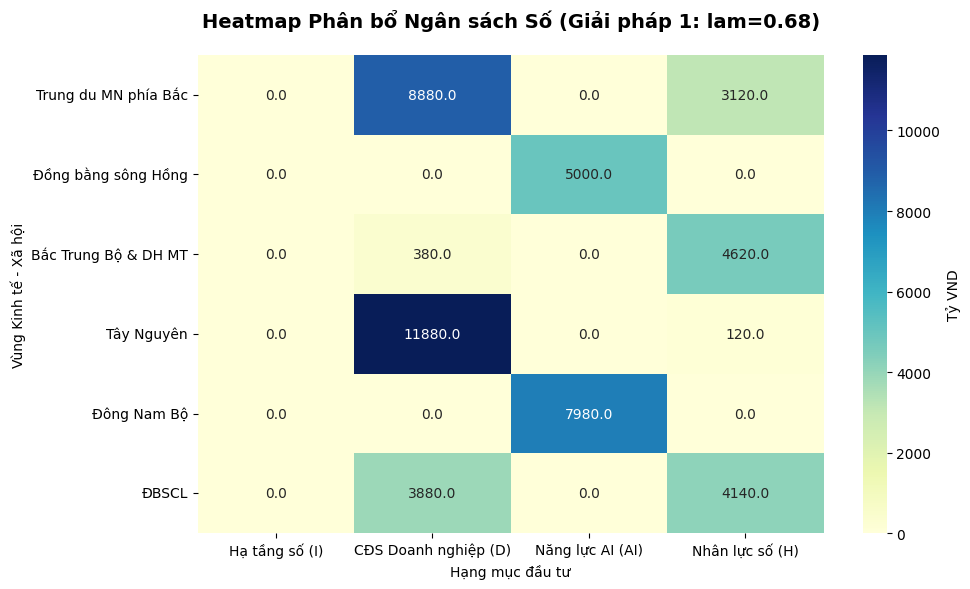

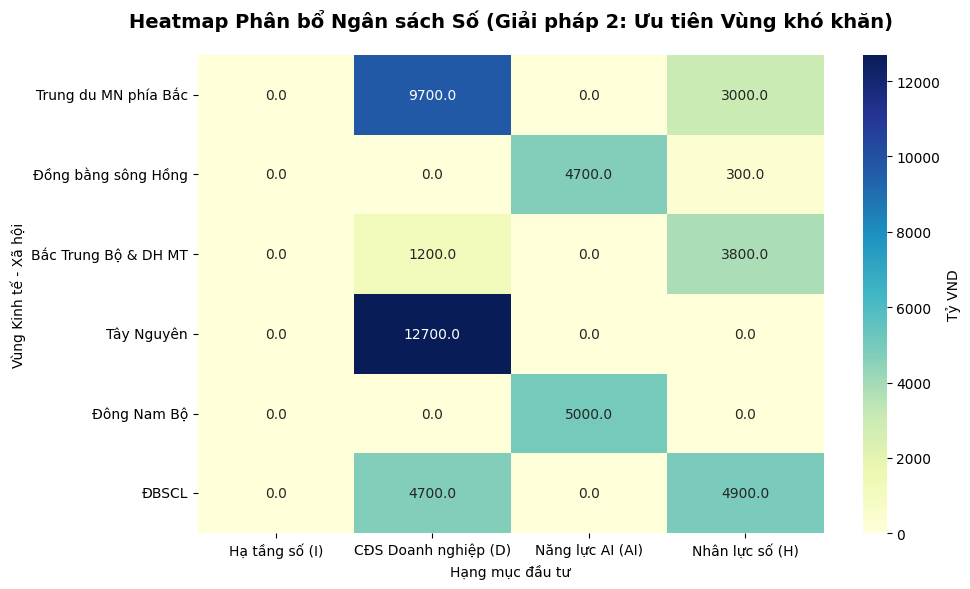

Đã lưu Heatmap vào D:\aideom_vn\outputs thành công.


In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Đường dẫn đến thư mục outputs theo cấu trúc F1.4 [1, 2]
# Sử dụng '..' để thoát khỏi thư mục 'notebooks' và đi vào 'outputs' trong 'aideom_vn'
output_dir = os.path.join('..', 'outputs')

# Tạo thư mục outputs nếu chưa tồn tại
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['Hạ tầng số (I)', 'CĐS Doanh nghiệp (D)', 'Năng lực AI (AI)', 'Nhân lực số (H)']

# Dữ liệu Giải pháp 1 (lam = 0.68)
data1 = np.array([
    [0.0, 8880.0, 0.0, 3120.0],
    [0.0, 0.0, 5000.0, 0.0],
    [0.0, 380.0, 0.0, 4620.0],
    [0.0, 11880.0, 0.0, 120.0],
    [0.0, 0.0, 7980.0, 0.0],
    [0.0, 3880.0, 0.0, 4140.0]
])

# Dữ liệu Giải pháp 2 (Nới trần ngân sách Tây Nguyên 12.700 tỷ, lam = 0.7)
data2 = np.array([
    [0.0, 9700.0, 0.0, 3000.0],
    [0.0, 0.0, 4700.0, 300.0],
    [0.0, 1200.0, 0.0, 3800.0],
    [0.0, 12700.0, 0.0, 0.0],
    [0.0, 0.0, 5000.0, 0.0],
    [0.0, 4700.0, 0.0, 4900.0]
])

def draw_and_save_heatmap(data, title, filename):
    df = pd.DataFrame(data, index=regions, columns=items)
    plt.figure(figsize=(10, 6))
    sns.heatmap(df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Tỷ VND'})
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Vùng Kinh tế - Xã hội')
    plt.xlabel('Hạng mục đầu tư')
    plt.tight_layout()
    
    # Lưu file vào đúng đường dẫn đã xác định [1, 2]
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300)
    plt.show()

# Thực hiện vẽ và lưu
draw_and_save_heatmap(data1, "Heatmap Phân bổ Ngân sách Số (Giải pháp 1: lam=0.68)", "heatmap_solution_1.png")
draw_and_save_heatmap(data2, "Heatmap Phân bổ Ngân sách Số (Giải pháp 2: Ưu tiên Vùng khó khăn)", "heatmap_solution_2.png")

print(f"Đã lưu Heatmap vào {os.path.abspath(output_dir)} thành công.")

In [10]:
import cvxpy as cp
import numpy as np
import pandas as pd
import os

# 1. Thiết lập cấu trúc thư mục theo Phụ lục F1.4 [2]
# '..' để lùi lại từ thư mục 'notebooks' vào thư mục mẹ 'aideom_vn', sau đó vào 'outputs'
output_dir = os.path.join('..', 'outputs')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Dữ liệu chuẩn từ Bảng 4.3 [3]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], 
    [0.95, 1.25, 1.40, 1.05], 
    [1.05, 0.95, 0.85, 1.15], 
    [1.20, 0.75, 0.45, 1.35], 
    [0.90, 1.30, 1.55, 1.00], 
    [1.10, 0.85, 0.65, 1.25]
])

# 3. Khai báo biến và hàm mục tiêu
x = cp.Variable((6, 4), nonneg=True)
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, x)))

# 4. Các ràng buộc tiêu chuẩn C1-C4 (ĐÃ BỎ C5) [4]
constraints = [
    cp.sum(x) <= 50000,                      # (C1) Tổng ngân sách
    cp.sum(x, axis=1) >= 5000,               # (C2) Sàn ngân sách mỗi vùng
    cp.sum(x, axis=1) <= 12000,              # (C3) Trần ngân sách mỗi vùng
    cp.sum(x[:, 3]) >= 12000                 # (C4) Sàn nhân lực số quốc gia
]

# 5. Giải bằng solver HiGHS [5]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.HIGHS)

# 6. In kết quả và Lưu ma trận
if prob.status == 'optimal':
    print(f"--- KẾT QUẢ TỐI ƯU KHÔNG CÓ RÀNG BUỘC C5 ---")
    print(f"Z* = {prob.value:,.2f} tỷ VND\n")
    
    # Tạo DataFrame ma trận 6x4
    df_no_c5 = pd.DataFrame(x.value, index=regions, columns=items)
    
    print("--- MA TRẬN PHÂN BỔ TỐI ƯU (6x4) ---")
    print(df_no_c5.round(2))
    
    # Lưu ma trận vào thư mục aideom_vn/outputs/ dưới dạng CSV
    file_path = os.path.join(output_dir, 'matrix_no_c5.csv')
    df_no_c5.to_csv(file_path, encoding='utf-8-sig')
    
    print(f"\n[Thông báo] Ma trận đã được lưu tại: {os.path.abspath(file_path)}")
else:
    print(f"Không tìm thấy nghiệm tối ưu. Trạng thái: {prob.status}")

--- KẾT QUẢ TỐI ƯU KHÔNG CÓ RÀNG BUỘC C5 ---
Z* = 68,750.00 tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU (6x4) ---
                        I    D       AI        H
Trung du MN phía Bắc  0.0  0.0      0.0   5000.0
Đồng bằng sông Hồng   0.0  0.0  12000.0      0.0
Bắc Trung Bộ & DH MT  0.0  0.0      0.0   5000.0
Tây Nguyên            0.0  0.0      0.0  11000.0
Đông Nam Bộ           0.0  0.0  12000.0      0.0
ĐBSCL                 0.0  0.0      0.0   5000.0

[Thông báo] Ma trận đã được lưu tại: D:\aideom_vn\outputs\matrix_no_c5.csv


In [29]:
import cvxpy as cp
import numpy as np
import pandas as pd
import os

# 1. Thiết lập cấu trúc thư mục theo Phụ lục F1.4
output_dir = os.path.join('..', 'outputs')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Dữ liệu từ Bảng 4.3 và 4.2 [1, 2]
regions = ['Trung du MN phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ & DH MT', 
           'Tây Nguyên', 'Đông Nam Bộ', 'ĐBSCL']
items = ['I', 'D', 'AI', 'H']

beta_matrix = np.array([
    [1.15, 0.85, 0.55, 1.30], 
    [0.95, 1.25, 1.40, 1.05], 
    [1.05, 0.95, 0.85, 1.15], 
    [1.20, 0.75, 0.45, 1.35], 
    [0.90, 1.30, 1.55, 1.00], 
    [1.10, 0.85, 0.65, 1.25]
])

D0 = np.array([38, 78, 55, 32, 82, 48])
gamma, lam = 0.002, 0.7

# 3. Biến và Hàm mục tiêu
x = cp.Variable((6, 4), nonneg=True)
objective = cp.Maximize(cp.sum(cp.multiply(beta_matrix, x)))

# 4. Các ràng buộc (ĐÃ LOẠI BỎ C3)
constraints = [
    cp.sum(x) <= 50000,                      # (C1) Tổng ngân sách
    cp.sum(x, axis=1) >= 5000,               # (C2) Sàn ngân sách mỗi vùng
    # Ràng buộc C3 (Trần ngân sách) đã được lược bỏ theo yêu cầu
    cp.sum(x[:, 3]) >= 12000                 # (C4) Sàn nhân lực số
]

# (C5) Công bằng vùng miền (70%)
D_final = D0 + gamma * x[:, 1]
constraints.append(D_final >= lam * cp.max(D_final))

# 5. Giải bằng solver HiGHS
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.HIGHS)

# 6. In kết quả và Lưu ma trận
if prob.status == 'optimal':
    print(f"--- KẾT QUẢ TỐI ƯU KHÔNG CÓ RÀNG BUỘC C3 ---")
    print(f"Z* = {prob.value:,.2f} tỷ VND\n")
    
    df_result = pd.DataFrame(x.value, index=regions, columns=items)
    print("--- MA TRẬN PHÂN BỔ TỐI ƯU (6x4) ---")
    print(df_result.round(2))
    
    # Lưu kết quả
    file_path = os.path.join(output_dir, 'matrix_no_c3_lam07.csv')
    df_result.to_csv(file_path, encoding='utf-8-sig')
    print(f"\n[Thông báo] Đã lưu ma trận tại: {os.path.abspath(file_path)}")
else:
    print(f"Không tìm thấy nghiệm tối ưu. Trạng thái: {prob.status}")


--- KẾT QUẢ TỐI ƯU KHÔNG CÓ RÀNG BUỘC C3 ---
Z* = 52,555.00 tỷ VND

--- MA TRẬN PHÂN BỔ TỐI ƯU (6x4) ---
                        I        D      AI       H
Trung du MN phía Bắc  0.0   9700.0     0.0     0.0
Đồng bằng sông Hồng   0.0      0.0  4700.0   300.0
Bắc Trung Bộ & DH MT  0.0   1200.0     0.0  3800.0
Tây Nguyên            0.0  12700.0     0.0  7600.0
Đông Nam Bộ           0.0      0.0  5000.0     0.0
ĐBSCL                 0.0   4700.0     0.0   300.0

[Thông báo] Đã lưu ma trận tại: D:\aideom_vn\outputs\matrix_no_c3_lam07.csv
